# Air Pollution Forecasting: PM2.5 Prediction with LSTM and Transformer

## Overview
This notebook forecasts hourly PM2.5 air pollution levels for Beijing using two deep learning architectures: a stacked **LSTM** and a **Transformer encoder**. Both models are trained on a multivariate time-series dataset and evaluated against the same held-out test set, allowing a direct performance comparison.

## Goals
- Explore and understand the structure of the pollution dataset
- Preprocess the data: encoding, normalization, and sliding-window sequence creation
- Train and tune an LSTM and a Transformer for single-step ahead PM2.5 forecasting
- Evaluate both models using MAE, RMSE, MAPE, and R²
- Compare model performance and discuss trade-offs

## Dataset
Hourly measurements from the US Embassy in Beijing (2010–2014), including PM2.5 concentration alongside meteorological variables: dew point, temperature, pressure, wind direction, wind speed, snowfall, and rainfall.

## Notebook Structure
1. **Setup:** Imports and global configuration
2. **Exploratory Data Analysis:** Distributions, correlations, and trend visualization of raw data
3. **Data Preprocessing:** Encoding, train/val/test split, scaling, and sequence creation
4. **LSTM:** Model definition, training, and evaluation
5. **Transformer:** Model definition, training, and evaluation
6. **Model Comparison**: Side-by-side metrics and loss curves
7. **Discussion:** Findings and conclusions

## 1. Setup

Define imports, path configuration, and the global `CONFIG` dictionary that controls all hyperparameters (sequence length, batch size, model dimensions, learning rate, and training budget). Changing a value here propagates through the entire notebook.

All core logic lives in `src/`: preprocessing pipelines (`src/preprocessing.py`), PyTorch datasets (`src/dataset.py`), model definitions (`src/models/`), and the training loop (`src/trainer.py`). This notebook imports from those modules and focuses on orchestration, visualization, and analysis rather than implementation.

In [64]:
import sys
sys.path.insert(0, ".")

import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("default")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.preprocessing import load_and_encode, split_data, fit_scaler, make_sequences, inverse_scale_pollution
from src.dataset import PollutionDataset
from src.models.lstm_model import LSTMForecaster
from src.models.transformer_model import TransformerForecaster
from src.trainer import run_training, predict, compute_metrics

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [65]:
CONFIG = {
    # Data
    "seq_len": 24,
    "batch_size": 64,
    "train_frac": 0.70,
    "val_frac": 0.15,
    # Training
    "lr": 1e-3,
    "n_epochs": 50,
    "patience": 10,
    # LSTM
    "lstm_hidden": 64,
    "lstm_layers": 2,
    "lstm_dropout": 0.2,
    # Transformer
    "d_model": 64,
    "nhead": 4,
    "num_encoder_layers": 2,
    "dim_feedforward": 128,
    "transformer_dropout": 0.1,
}

## 2. Exploratory Data Analysis

Before modelling, this section examines the raw dataset to understand its structure, quality, and statistical properties. The PM2.5 time series, distribution and correlation of meteorological features with pollution levels, and a rolling-mean trend are all explored to surface longer-term seasonal patterns. The goal is to build intuition about the data that informs preprocessing and modelling decisions.

In [66]:
raw = pd.read_csv('data/LSTM-Multivariate_pollution.csv', parse_dates=['date'], index_col='date')
print(raw.shape)
raw.describe()

(43800, 8)


,pollution,dew,temp,press,wnd_spd,snow,rain
count,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,94.013516,1.828516,12.459041,1016.447306,23.894307,0.052763,0.195023
std,92.252276,14.429326,12.193384,10.271411,50.022729,0.760582,1.416247
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,24.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,68.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,132.250000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [67]:
raw.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43800 entries, 2010-01-02 00:00:00 to 2014-12-31 23:00:00
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pollution  43800 non-null  float64
 1   dew        43800 non-null  int64  
 2   temp       43800 non-null  float64
 3   press      43800 non-null  float64
 4   wnd_dir    43800 non-null  str    
 5   wnd_spd    43800 non-null  float64
 6   snow       43800 non-null  int64  
 7   rain       43800 non-null  int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 3.0 MB


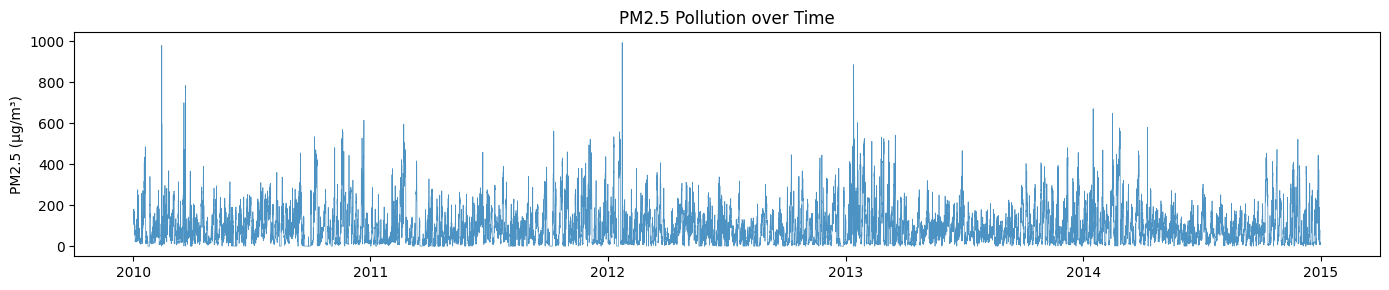

In [68]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(raw['pollution'], linewidth=0.5, alpha=0.8)
ax.set(title='PM2.5 Pollution over Time', ylabel='PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

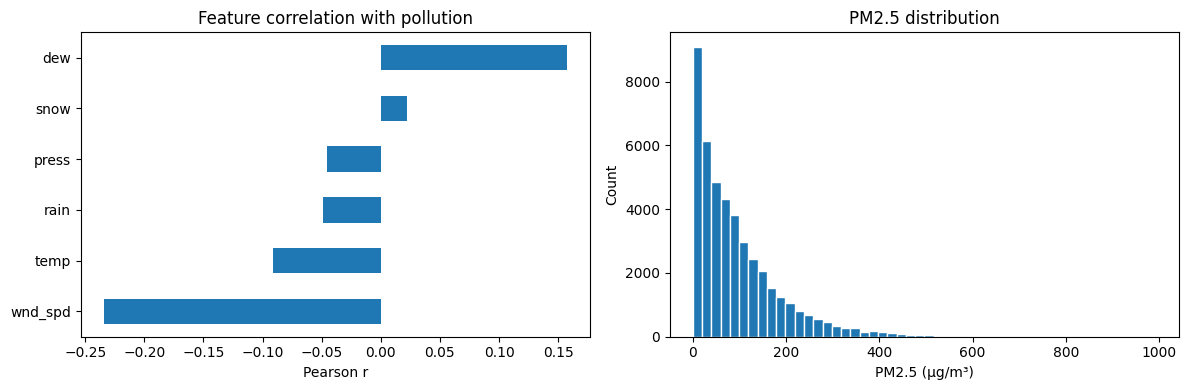

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

numeric = raw.drop(columns=['wnd_dir'])
corr = numeric.corr()[['pollution']].drop('pollution').sort_values('pollution')
corr.plot(kind='barh', ax=axes[0], legend=False)
axes[0].set(title='Feature correlation with pollution', xlabel='Pearson r')

axes[1].hist(raw['pollution'], bins=50, edgecolor='white')
axes[1].set(title='PM2.5 distribution', xlabel='PM2.5 (μg/m³)', ylabel='Count')

plt.tight_layout()
plt.show()

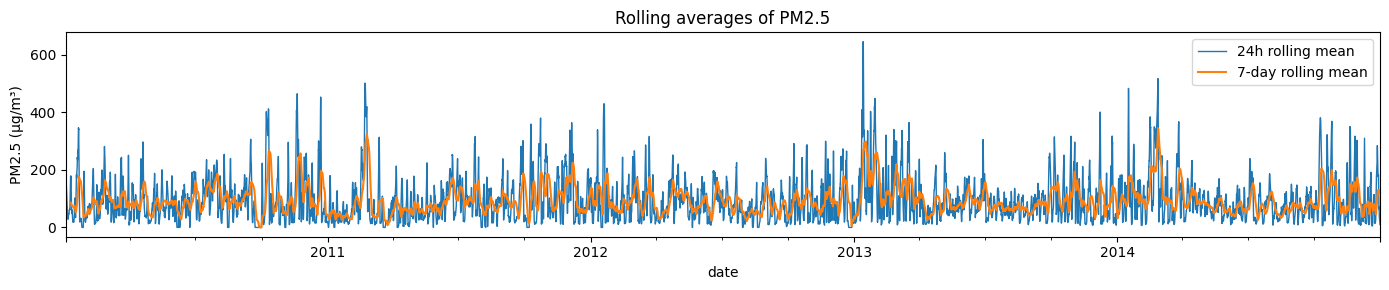

In [70]:
fig, ax = plt.subplots(figsize=(14, 3))
raw['pollution'].rolling(24).mean().plot(ax=ax, label='24h rolling mean', linewidth=1)
raw['pollution'].rolling(24*7).mean().plot(ax=ax, label='7-day rolling mean', linewidth=1.5)
ax.set(title='Rolling averages of PM2.5', ylabel='PM2.5 (μg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

### Key Findings

- **Dataset**: 43,800 hourly records spanning 2010–2014 with no missing values across all 8 features.
- **PM2.5 distribution**: Heavily right-skewed - mean ~94 μg/m³, median ~68 μg/m³, with extreme spikes up to 994 μg/m³. The high standard deviation (~92) reflects frequent pollution events well above the mean.
- **Correlations**: Dew point shows the strongest positive correlation with PM2.5. Wind speed is negatively correlated — higher wind disperses pollutants. Temperature and pressure show weaker associations.
- **Precipitation**: Snow and rain are very sparse (75th percentile is 0 for both), so they contribute little signal on average despite occasional high values.
- **Seasonality**: The rolling averages reveal a clear seasonal pattern — pollution peaks in winter months and drops in summer, consistent with heating emissions and reduced atmospheric mixing in cold weather.
- **Wind speed outliers**: Max wind speed of 585.6 μg/m³ against a mean of 23.9 suggests a small number of extreme events; MinMax scaling will compress these appropriately.

## 3. Preprocessing

The raw CSV is loaded and the categorical wind direction feature is one-hot encoded into four binary columns (`NE`, `NW`, `SE`, `cv`), bringing the total feature count to 11. The 43,800 hourly records are then split chronologically into train (30,659), validation (6,571), and test (6,570) sets to prevent leakage. A `MinMaxScaler` fitted on training data normalises all features to [0, 1] before a 24-hour sliding window converts each split into input tensors of shape `(samples, 24, 11)` and scalar PM2.5 targets.

In [71]:
df = load_and_encode('data/LSTM-Multivariate_pollution.csv')
print('Columns:', df.columns.tolist())
print('Shape:', df.shape)

Columns: ['pollution', 'dew', 'temp', 'press', 'wnd_spd', 'snow', 'rain', 'wnd_dir_NE', 'wnd_dir_NW', 'wnd_dir_SE', 'wnd_dir_cv']
Shape: (43800, 11)


In [72]:
train_df, val_df, test_df = split_data(df, CONFIG['train_frac'], CONFIG['val_frac'])
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 30,659 | Val: 6,571 | Test: 6,570


In [73]:
scaler, train_arr, val_arr, test_arr = fit_scaler(train_df, val_df, test_df)

X_train, y_train = make_sequences(train_arr, CONFIG['seq_len'])
X_val,   y_val   = make_sequences(val_arr,   CONFIG['seq_len'])
X_test,  y_test  = make_sequences(test_arr,  CONFIG['seq_len'])

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}   | y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')

X_train: (30635, 24, 11) | y_train: (30635,)
X_val:   (6547, 24, 11)   | y_val:   (6547,)
X_test:  (6546, 24, 11)  | y_test:  (6546,)


In [74]:
train_loader = DataLoader(PollutionDataset(X_train, y_train), batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(PollutionDataset(X_val,   y_val),   batch_size=CONFIG['batch_size'], shuffle=False)
test_loader  = DataLoader(PollutionDataset(X_test,  y_test),  batch_size=CONFIG['batch_size'], shuffle=False)

## 4. LSTM

A stacked two-layer LSTM (hidden size 64, dropout 0.2) with 53,057 trainable parameters, trained end-to-end to predict the next PM2.5 value from the previous 24 hourly observations. Two layers are used to allow the network to learn hierarchical temporal patterns — the first layer captures short-term dependencies while the second abstracts longer-range dynamics. A hidden size of 64 balances model capacity against overfitting risk on this dataset size, and dropout of 0.2 is applied between layers as regularization. A sequence length of 24 hours corresponds to one full day, a natural window for capturing diurnal pollution cycles.

### 4.1 Training

Trained with Adam (lr=1e-3) and MSE loss. A `ReduceLROnPlateau` scheduler halves the learning rate after 5 epochs without validation improvement, and early stopping with patience 10 prevents overfitting.

In [75]:
input_size = X_train.shape[2]

lstm_model = LSTMForecaster(
    input_size=input_size,
    hidden_size=CONFIG["lstm_hidden"],
    num_layers=CONFIG["lstm_layers"],
    dropout=CONFIG["lstm_dropout"],
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(lstm_model)
print(f"\nTrainable parameters: {total_params:,}")

LSTMForecaster(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 53,057


In [22]:
criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=CONFIG["lr"])
lstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(lstm_optimizer, patience=5, factor=0.5)

lstm_train_losses, lstm_val_losses, lstm_best_weights = run_training(
    lstm_model, train_loader, val_loader,
    lstm_optimizer, criterion, lstm_scheduler,
    n_epochs=CONFIG["n_epochs"],
    device=DEVICE,
    patience=CONFIG["patience"],
)

torch.save(lstm_best_weights, "model_weights/lstm_best.pt")
print("Best weights saved to model_weights/lstm_best.pt")

Epoch   1 | train loss: 0.003541 | val loss: 0.001179
Epoch   5 | train loss: 0.000892 | val loss: 0.000683
Epoch  10 | train loss: 0.000840 | val loss: 0.000584
Epoch  15 | train loss: 0.000810 | val loss: 0.000630
Epoch  20 | train loss: 0.000756 | val loss: 0.000550
Epoch  25 | train loss: 0.000731 | val loss: 0.000549
Epoch  30 | train loss: 0.000703 | val loss: 0.000519
Epoch  35 | train loss: 0.000697 | val loss: 0.000526
Epoch  40 | train loss: 0.000672 | val loss: 0.000531
Early stopping at epoch 42 (no improvement for 10 epochs)
Best weights saved to model_weights/lstm_best.pt


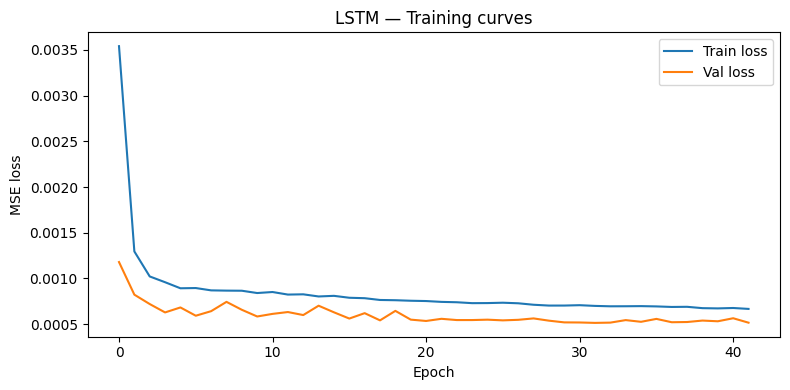

In [76]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_train_losses, label="Train loss")
ax.plot(lstm_val_losses,   label="Val loss")
ax.set(title="LSTM — Training curves", xlabel="Epoch", ylabel="MSE loss")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Evaluation

The best checkpoint (lowest validation loss) is loaded and evaluated on the held-out test set. Predictions are inverse-scaled back to PM2.5 units before computing metrics.

In [77]:
lstm_model.load_state_dict(torch.load("model_weights/lstm_best.pt", map_location=DEVICE))

lstm_preds_scaled = predict(lstm_model, test_loader, DEVICE)
lstm_preds = inverse_scale_pollution(scaler, lstm_preds_scaled)
y_test_original = inverse_scale_pollution(scaler, y_test)

lstm_metrics = compute_metrics(y_test_original, lstm_preds)
print("LSTM Test Metrics:")
for k, v in lstm_metrics.items():
    print(f"  {k}: {v:.4f}")

LSTM Test Metrics:
  MAE: 11.1157
  RMSE: 21.2557
  MAPE: 22.4308
  R2: 0.9273


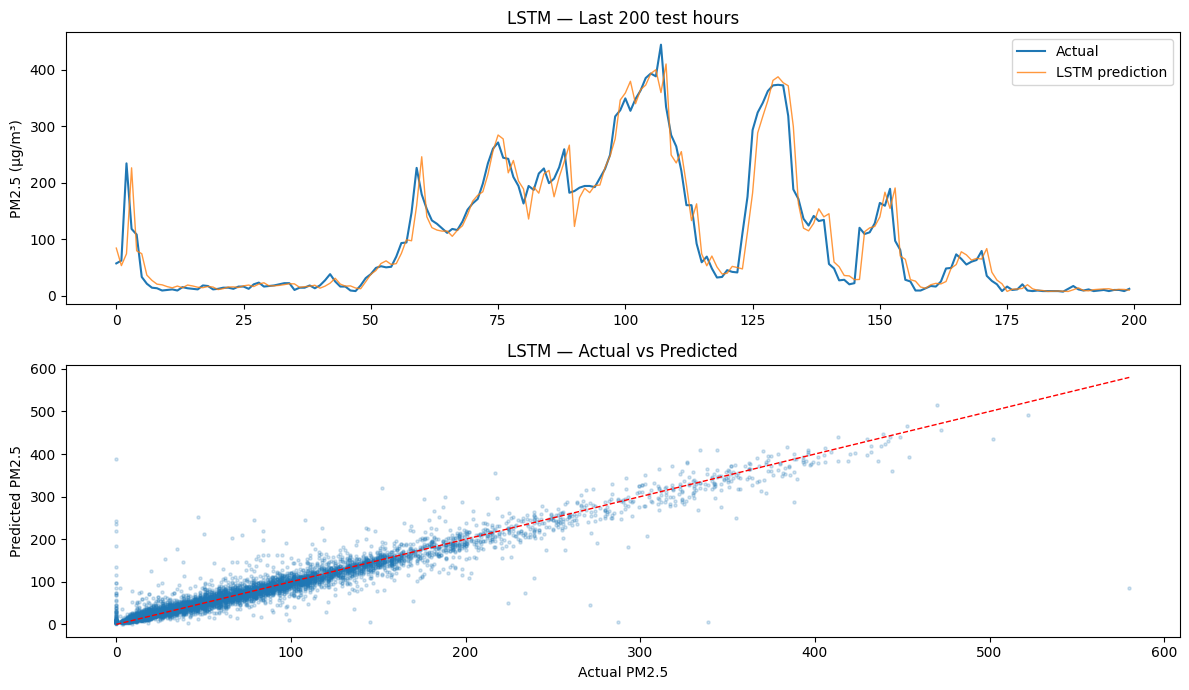

In [78]:
n_show = 200
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(y_test_original[-n_show:], label='Actual', linewidth=1.5)
axes[0].plot(lstm_preds[-n_show:],      label='LSTM prediction', linewidth=1, alpha=0.8)
axes[0].set(title=f'LSTM — Last {n_show} test hours', ylabel='PM2.5 (μg/m³)')
axes[0].legend()

axes[1].scatter(y_test_original, lstm_preds, alpha=0.2, s=5)
lims = [min(y_test_original.min(), lstm_preds.min()),
        max(y_test_original.max(), lstm_preds.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1)
axes[1].set(title='LSTM — Actual vs Predicted', xlabel='Actual PM2.5', ylabel='Predicted PM2.5')

plt.tight_layout()
plt.show()

### 4.3 Results Analysis

The LSTM achieves strong predictive performance on the held-out test set. An R² of 0.9273 indicates the model explains over 92% of the variance in PM2.5 concentration, and an MAE of 11.12 μg/m³ is modest relative to the dataset mean of ~94 μg/m³. The gap between MAE and RMSE (21.26 μg/m³) points to occasional large errors — the squared penalty in RMSE amplifies prediction misses during sharp pollution spikes, which are difficult to anticipate from the previous 24 hours alone. The MAPE of 22.43% reflects this behaviour at the extremes, where absolute values are low and relative errors grow. Training converged steadily over 42 epochs before early stopping triggered, with validation loss dropping from 0.001179 at epoch 1 to 0.000519 at epoch 30 before plateauing — a sign the model was well-regularized rather than overfit.

## 5. Transformer

An encoder-only Transformer with sinusoidal positional encoding and 67,777 trainable parameters, trained on the same sequences and objective as the LSTM for a direct comparison. The architecture uses a linear projection to map the 11 input features into a `d_model=64` embedding space, followed by 2 Transformer encoder layers with 4 attention heads and a feedforward dimension of 128. Two encoder layers mirror the LSTM depth to keep the comparison fair. Multi-head attention with 4 heads allows the model to attend to different temporal patterns simultaneously, while sinusoidal positional encoding injects sequence order since the Transformer has no built-in notion of time. Dropout of 0.1 is applied within each encoder layer as a regularization measure.

### 5.1 Training

Same training setup as the LSTM: Adam (lr=1e-3), MSE loss, `ReduceLROnPlateau` scheduler (patience=5, factor=0.5), and early stopping with patience 10.

In [79]:
transformer_model = TransformerForecaster(
    input_size=input_size,
    d_model=CONFIG["d_model"],
    nhead=CONFIG["nhead"],
    num_encoder_layers=CONFIG["num_encoder_layers"],
    dim_feedforward=CONFIG["dim_feedforward"],
    dropout=CONFIG["transformer_dropout"],
).to(DEVICE)

total_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(transformer_model)
print(f"\nTrainable parameters: {total_params:,}")

TransformerForecaster(
  (input_proj): Linear(in_features=11, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 67,777


In [30]:
criterion = nn.MSELoss()
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=CONFIG["lr"])
transformer_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(transformer_optimizer, patience=5, factor=0.5)

tr_train_losses, tr_val_losses, tr_best_weights = run_training(
    transformer_model, train_loader, val_loader,
    transformer_optimizer, criterion, transformer_scheduler,
    n_epochs=CONFIG["n_epochs"],
    device=DEVICE,
    patience=CONFIG["patience"],
)

torch.save(tr_best_weights, "model_weights/transformer_best.pt")
print("Best weights saved to model_weights/transformer_best.pt")

Epoch   1 | train loss: 0.007236 | val loss: 0.001177
Epoch   5 | train loss: 0.001014 | val loss: 0.001185
Epoch  10 | train loss: 0.000926 | val loss: 0.000643
Epoch  15 | train loss: 0.000851 | val loss: 0.000613
Epoch  20 | train loss: 0.000829 | val loss: 0.000657
Epoch  25 | train loss: 0.000755 | val loss: 0.000546
Epoch  30 | train loss: 0.000728 | val loss: 0.000619
Epoch  35 | train loss: 0.000687 | val loss: 0.000573
Epoch  40 | train loss: 0.000662 | val loss: 0.000524
Epoch  45 | train loss: 0.000649 | val loss: 0.000533
Epoch  50 | train loss: 0.000622 | val loss: 0.000530
Best weights saved to model_weights/transformer_best.pt


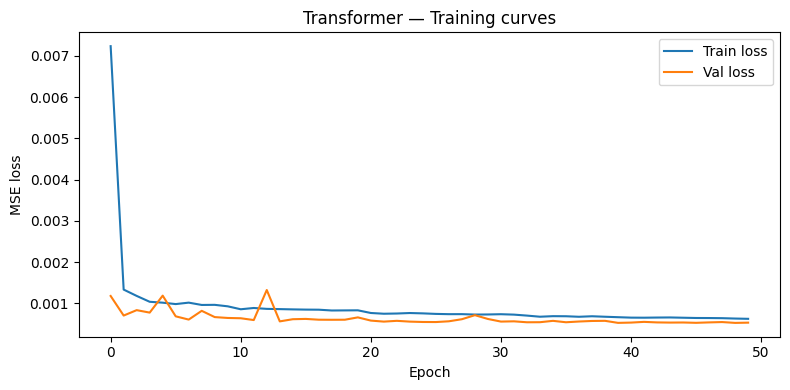

In [80]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tr_train_losses, label="Train loss")
ax.plot(tr_val_losses,   label="Val loss")
ax.set(title="Transformer — Training curves", xlabel="Epoch", ylabel="MSE loss")
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Evaluation

The best checkpoint (lowest validation loss) is loaded and evaluated on the held-out test set under identical conditions as the LSTM. Predictions are inverse-scaled back to PM2.5 units before computing metrics.

In [81]:
transformer_model.load_state_dict(torch.load("model_weights/transformer_best.pt", map_location=DEVICE))

tr_preds_scaled = predict(transformer_model, test_loader, DEVICE)
tr_preds = inverse_scale_pollution(scaler, tr_preds_scaled)

tr_metrics = compute_metrics(y_test_original, tr_preds)
print("Transformer Test Metrics:")
for k, v in tr_metrics.items():
    print(f"  {k}: {v:.4f}")

Transformer Test Metrics:
  MAE: 10.9065
  RMSE: 21.3893
  MAPE: 20.8477
  R2: 0.9264


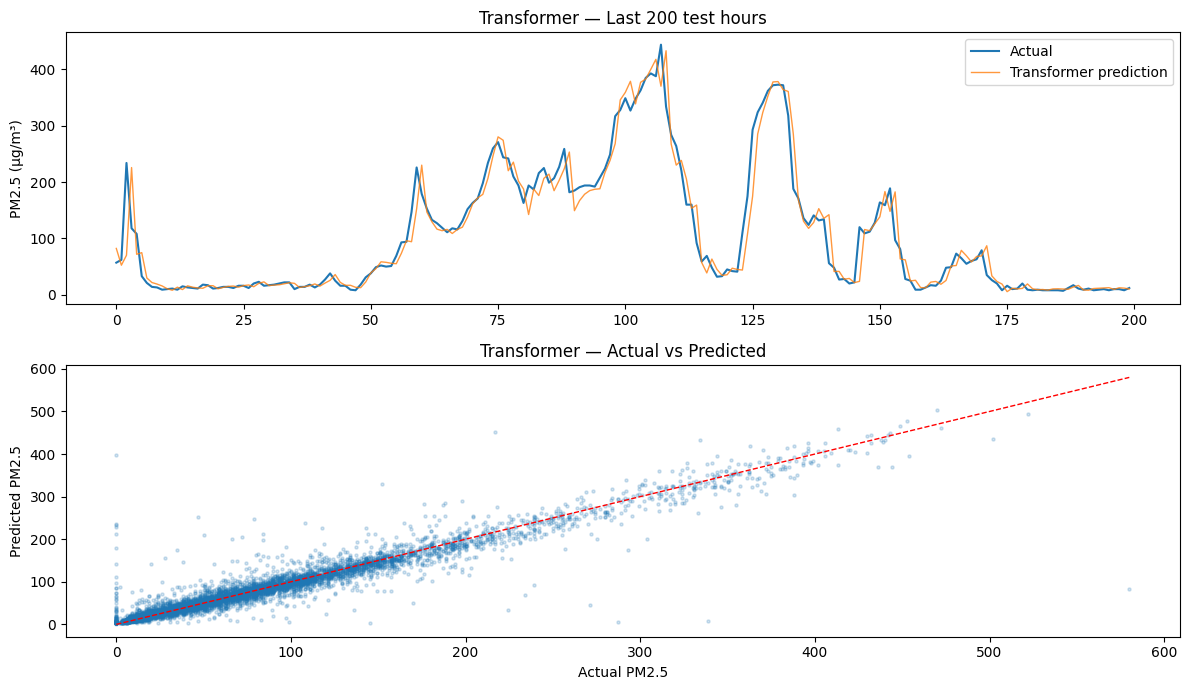

In [82]:
n_show = 200
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(y_test_original[-n_show:], label="Actual", linewidth=1.5)
axes[0].plot(tr_preds[-n_show:],        label="Transformer prediction", linewidth=1, alpha=0.8)
axes[0].set(title=f"Transformer — Last {n_show} test hours", ylabel="PM2.5 (μg/m³)")
axes[0].legend()

axes[1].scatter(y_test_original, tr_preds, alpha=0.2, s=5)
lims = [min(y_test_original.min(), tr_preds.min()),
        max(y_test_original.max(), tr_preds.max())]
axes[1].plot(lims, lims, "r--", linewidth=1)
axes[1].set(title="Transformer — Actual vs Predicted", xlabel="Actual PM2.5", ylabel="Predicted PM2.5")

plt.tight_layout()
plt.show()

### 5.3 Results Analysis

The Transformer achieves solid predictive performance — an R² of 0.9264 indicates it explains over 92% of the variance in PM2.5 concentration. The MAE of 10.91 μg/m³ is reasonable relative to the dataset mean of ~94 μg/m³, and the MAPE of 20.85% reflects some difficulty at low-pollution periods where small absolute errors translate into large relative ones. Training ran the full 50 epochs without early stopping, with validation loss dropping from 0.001177 at epoch 1 to 0.000524 at epoch 40 before plateauing — showing steady but gradual convergence.

## 6. Model Comparison

Both models are evaluated on the same held-out test set under identical conditions. The table below reports MAE, RMSE, MAPE, and R² in original PM2.5 units, followed by overlaid training curves and a per-metric bar chart.

In [83]:
comparison = pd.DataFrame(
    {"LSTM": lstm_metrics, "Transformer": tr_metrics}
).T.round(4)
comparison

,MAE,RMSE,MAPE,R2
LSTM,11.1157,21.2557,22.4308,0.9273
Transformer,10.9065,21.3893,20.8477,0.9264


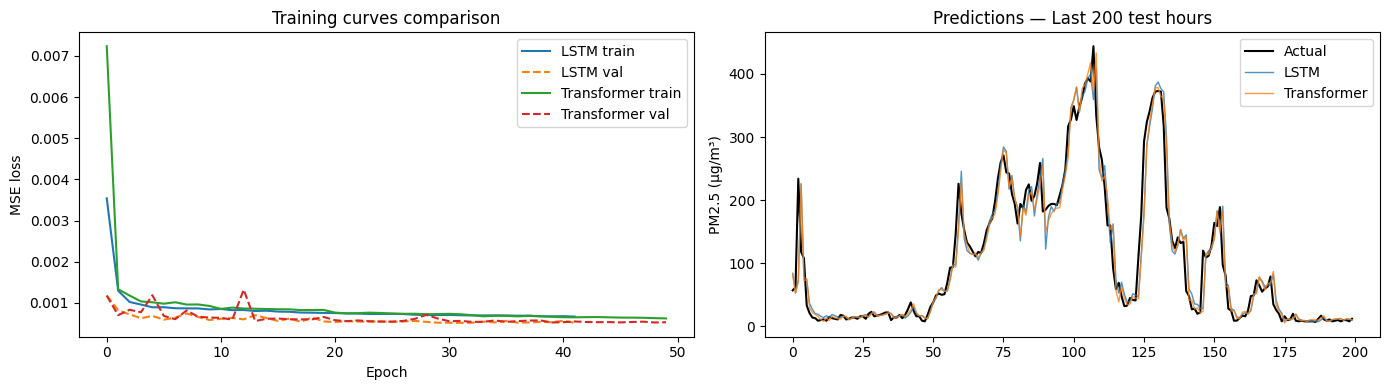

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_train_losses, label="LSTM train")
axes[0].plot(lstm_val_losses,   label="LSTM val",         linestyle="--")
axes[0].plot(tr_train_losses,   label="Transformer train")
axes[0].plot(tr_val_losses,     label="Transformer val",  linestyle="--")
axes[0].set(title="Training curves comparison", xlabel="Epoch", ylabel="MSE loss")
axes[0].legend()

n_show = 200
axes[1].plot(y_test_original[-n_show:], label="Actual",      linewidth=1.5, color="black")
axes[1].plot(lstm_preds[-n_show:],      label="LSTM",        linewidth=1, alpha=0.8)
axes[1].plot(tr_preds[-n_show:],        label="Transformer", linewidth=1, alpha=0.8)
axes[1].set(title=f"Predictions — Last {n_show} test hours", ylabel="PM2.5 (μg/m³)")
axes[1].legend()

plt.tight_layout()
plt.show()

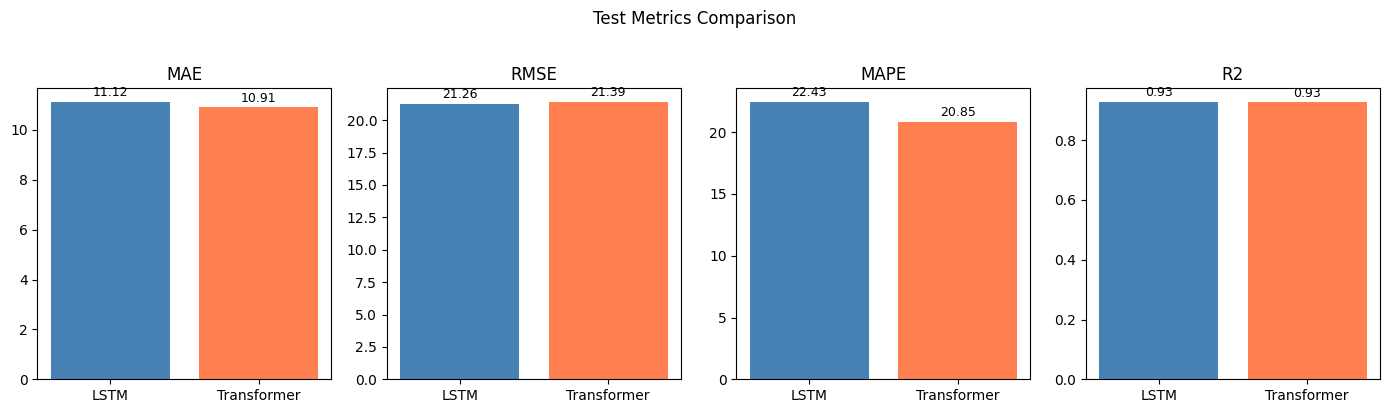

In [85]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
metrics_list = list(lstm_metrics.keys())

for ax, metric in zip(axes, metrics_list):
    values = [lstm_metrics[metric], tr_metrics[metric]]
    bars = ax.bar(["LSTM", "Transformer"], values, color=["steelblue", "coral"])
    ax.set_title(metric)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Test Metrics Comparison", y=1.02)
plt.tight_layout()
plt.show()

## 7. Discussion

**Performance**: Both models achieve comparable results. The Transformer has a lower MAE (10.91 vs 11.12 μg/m³) and MAPE (20.85% vs 22.43%), while the LSTM has a marginally better RMSE (21.26 vs 21.39 μg/m³) and R² (0.9273 vs 0.9264). Neither model clearly dominates.

**Training**: The LSTM converged faster and more stably, reaching its best checkpoint at epoch 42. The Transformer ran the full 50 epochs with higher variance early in training, consistent with self-attention requiring more iterations to stabilise on smaller datasets.

**Limitations**: Both models predict only one step ahead and struggle with sharp pollution spikes, as evidenced by the MAE–RMSE gap. A fixed 24-hour window may not capture the long-range dependencies driving sudden pollution events.

**Next steps**: multi-step forecasting, hyperparameter search, and incorporating additional features such as traffic or industrial activity data.

**Conclusion**: For this dataset and task, the LSTM is the more practical choice — it trains faster, converges more stably, and achieves slightly better RMSE and R² with a simpler, smaller architecture. That said, the Transformer reaches competitive performance using a general-purpose architecture not specifically designed for sequential data. Its ability to attend to all timesteps simultaneously makes it more extensible, and with larger datasets or longer sequences it would likely become the stronger model.